# 02 — Anchor Event Identification

Identifies **anchor posts** — high-engagement negative disclosure posts that serve as causal anchors for DiD analysis.

**Definition (from paper §4.3):**
1. Post contains keywords associated with negative admissions experiences
2. Post scores above distress threshold on ≥1 dimension (anxiety/depression/stress)

**Exposed user**: active that week AND interacted with the anchor thread  
**Unexposed user**: active that week but did NOT interact with anchor threads

**Note on thread linking**: Since our dataset does not include `link_id` on comments, we use the `outcome` field and keyword matching to identify users who self-disclosed negative outcomes. Exposure is approximated by same-week activity.

**Input:** `scored_corpus.parquet` (from notebook 01)  
**Output:** `anchor_posts.parquet`, `user_weekly_scores.parquet`, `exposure_labels.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
from pathlib import Path

ROOT     = Path('..').resolve()
PIPE_DIR = ROOT / 'pipeline'

df = pd.read_parquet(PIPE_DIR / 'scored_corpus.parquet')
print(f'Loaded {len(df):,} records')
df[['kind', 'outcome', 'vader_compound', 'distress_score']].head(3)

Loaded 467,525 records


,kind,outcome,vader_compound,distress_score
0,post,Unknown,0.9795,0.046
1,post,Unknown,0.4404,0.000
2,post,Unknown,0.4939,0.086


## 1) Anchor post identification

Two-step filter:
1. Keyword filter (negative admissions keywords)
2. Distress threshold: `distress_score > threshold` OR `vader_compound < threshold`

In [2]:
# Keywords associated with negative admissions experiences (§4.3)
NEGATIVE_KEYWORDS = [
    r'\breject(?:ed|ion)\b',
    r'\bdeclin(?:ed|ing)\b',
    r'\bwaitlist(?:ed)?\b',
    r'\bfunding\s+(?:lost|cut|removed|denied|gap|issue)\b',
    r'\bno\s+funding\b',
    r'\bstipend\b',
    r'\bwithdrew?\s+(?:offer|admission)\b',
    r'\bacceptance\s+rate\b',
    r'\bno\s+(?:offer|response|interview)\b',
    r'\bsilence\s+from\b',
    r'\bnot\s+(?:accepted|admitted|selected)\b',
    r'\bgave\s+up\b',
    r'\bmental\s+health\b',
    r'\banxi(?:ous|ety)\b',
    r'\bdepress(?:ed|ing|ion)\b',
    r'\bstress(?:ed|ful)?\b',
    r'\bfalling\s+apart\b',
    r'\bbreaking\s+down\b',
    r'\bcan(?:\'t|not)\s+(?:take|handle|cope)\b',
]

keyword_pattern = re.compile('|'.join(NEGATIVE_KEYWORDS), re.IGNORECASE)

posts_only = df[df['kind'] == 'post'].copy()

posts_only['has_neg_keyword'] = posts_only['clean_text'].str.contains(keyword_pattern, na=False)

print(f'Posts with negative keywords: {posts_only["has_neg_keyword"].sum():,} / {len(posts_only):,}')
print(f'  = {posts_only["has_neg_keyword"].mean():.1%} of all posts')

Posts with negative keywords: 15,187 / 88,218
  = 17.2% of all posts


In [3]:
# Distress threshold (tune as needed)
# We use: vader_compound < -0.05 (negative) OR distress_score (vader_neg) > 0.1
DISTRESS_COMPOUND_THRESH = -0.05
DISTRESS_NEG_THRESH      = 0.10

posts_only['is_distressed'] = (
    (posts_only['vader_compound'] < DISTRESS_COMPOUND_THRESH) |
    (posts_only['distress_score'] > DISTRESS_NEG_THRESH)
)

# Anchor posts: keyword + distressed
anchor_posts = posts_only[
    posts_only['has_neg_keyword'] & posts_only['is_distressed']
].copy()

# Also include posts with outcome=Rejected (self-labeled)
outcome_anchors = posts_only[
    posts_only['outcome'].isin(['Rejected', 'Waitlisted']) & posts_only['is_distressed']
].copy()

anchor_posts = pd.concat([anchor_posts, outcome_anchors]).drop_duplicates('record_id')

print(f'Anchor posts identified: {len(anchor_posts):,}')
print(f'Unique anchor authors:   {anchor_posts["author"].nunique():,}')
anchor_posts[['created_date', 'week', 'outcome', 'vader_compound', 'distress_score', 'clean_text']].head()

Anchor posts identified: 7,075
Unique anchor authors:   5,471


,created_date,week,outcome,vader_compound,distress_score,clean_text
51,2023-08-02,2023-W31,Accepted,-0.8505,0.062,MSW to PhD in Psychology I have a Masters in S...
78,2023-08-02,2023-W31,Accepted,0.2342,0.110,Is USC worth it? Need advice I am an internati...
88,2023-08-02,2023-W31,Accepted,-0.7974,0.107,What're my chances of getting into an experime...
110,2023-08-03,2023-W31,Accepted,-0.8701,0.072,"Do you know if any expert can tell me? Hello, ..."
146,2023-08-03,2023-W31,Unknown,0.0489,0.116,Is junior year too late to do undergraduate re...


Saved anchor_posts.parquet


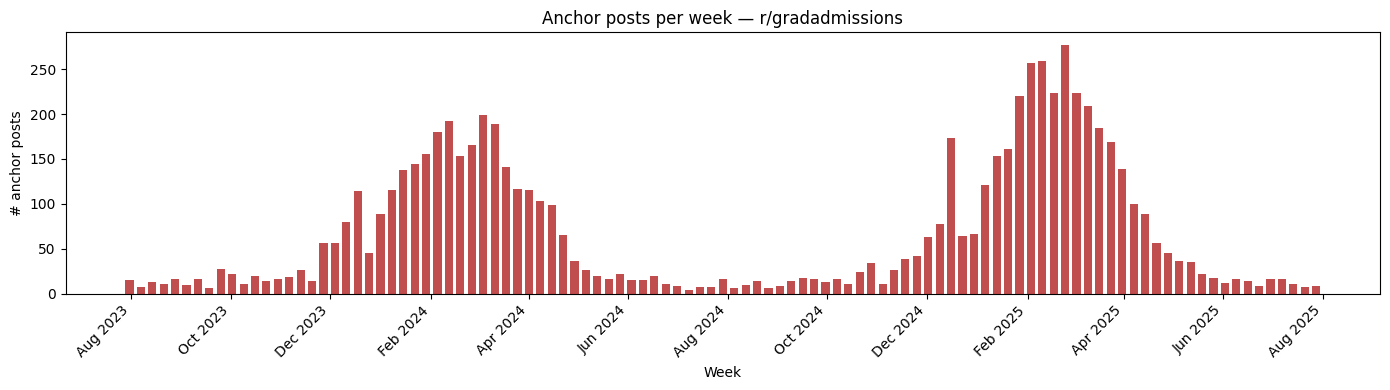

In [4]:
# Save anchor posts
anchor_posts.to_parquet(PIPE_DIR / 'anchor_posts.parquet', index=False)
print('Saved anchor_posts.parquet')

# Distribution of anchor posts by week
anchor_weekly = anchor_posts.groupby('week', sort=True).size().reset_index(name='n_anchors')
anchor_weekly['week_dt'] = pd.to_datetime(anchor_weekly['week'] + '-1', format='%G-W%V-%u', utc=True)
anchor_weekly = anchor_weekly.sort_values('week_dt')

plt.figure(figsize=(14, 4))
plt.bar(anchor_weekly['week_dt'], anchor_weekly['n_anchors'], width=5, color='firebrick', alpha=0.8)
plt.title('Anchor posts per week — r/gradadmissions')
plt.xlabel('Week'); plt.ylabel('# anchor posts')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PIPE_DIR / 'fig_anchor_posts_per_week.png', dpi=150, bbox_inches='tight')
plt.show()

## 2) User-level weekly distress scores

For each (author, week) pair, compute mean distress metrics across all their posts+comments.
This is the primary outcome variable for DiD.

In [5]:
user_weekly = (
    df.groupby(['author', 'week'], sort=True)
    .agg(
        n_posts        = ('record_id',       'count'),
        mean_compound  = ('vader_compound',  'mean'),
        mean_distress  = ('distress_score',  'mean'),
        pct_negative   = ('is_negative',     'mean'),
        min_compound   = ('vader_compound',  'min'),
    )
    .reset_index()
)

user_weekly['week_dt'] = pd.to_datetime(
    user_weekly['week'] + '-1', format='%G-W%V-%u', utc=True
)

print(f'User-week observations: {len(user_weekly):,}')
print(f'Unique users: {user_weekly["author"].nunique():,}')
user_weekly.head()

User-week observations: 210,133
Unique users: 90,539


,author,week,n_posts,mean_compound,mean_distress,pct_negative,min_compound,week_dt
0,---Imperator---,2023-W45,3,0.749933,0.026667,0.00,0.4429,2023-11-06 00:00:00+00:00
1,---Imperator---,2024-W02,2,-0.201100,0.076000,0.50,-0.4022,2024-01-08 00:00:00+00:00
2,---anastasia---,2024-W12,1,0.645800,0.000000,0.00,0.6458,2024-03-18 00:00:00+00:00
3,--Gizmo--,2024-W13,4,0.435750,0.087000,0.25,-0.7074,2024-03-25 00:00:00+00:00
4,--Mason--,2025-W06,2,0.364700,0.057500,0.00,0.3291,2025-02-03 00:00:00+00:00


In [6]:
user_weekly.to_parquet(PIPE_DIR / 'user_weekly_scores.parquet', index=False)
print('Saved user_weekly_scores.parquet')

Saved user_weekly_scores.parquet


## 3) Exposure classification

**Strategy** (adapted for available data):
- An anchor post creates an "anchor event" in week W.
- **Exposed user**: a user who *authored* an anchor post (self-disclosure) OR who was active the same week as an anchor post. Since we lack thread-level linking, we use the anchor-author themselves as the primary exposed unit.
- **Unexposed user**: active the same week but did NOT author any anchor post.

This captures the most direct form of negative disclosure and is closer to what the paper measures with `outcome` labels.

In [7]:
# Anchor authors and their event weeks
anchor_events = anchor_posts[['author', 'week', 'vader_compound', 'distress_score', 'outcome']].copy()
anchor_events = anchor_events.rename(columns={'author': 'anchor_author', 'week': 'event_week'})

# All users active each week
active_per_week = (
    df.groupby(['week', 'author'])
    .size()
    .reset_index(name='n_posts_that_week')
)

# Weeks that have at least one anchor post
anchor_weeks = set(anchor_posts['week'].unique())

# For each anchor week: exposed = anchor authors, unexposed = others active that week
records = []
for week in anchor_weeks:
    exposed_authors   = set(anchor_posts[anchor_posts['week'] == week]['author'])
    active_authors    = set(active_per_week[active_per_week['week'] == week]['author'])
    unexposed_authors = active_authors - exposed_authors

    for a in exposed_authors:
        records.append({'author': a, 'event_week': week, 'exposed': True})
    for a in unexposed_authors:
        records.append({'author': a, 'event_week': week, 'exposed': False})

exposure_df = pd.DataFrame(records)
exposure_df['week_dt'] = pd.to_datetime(
    exposure_df['event_week'] + '-1', format='%G-W%V-%u', utc=True
)

print(f'Total exposure records: {len(exposure_df):,}')
print(exposure_df['exposed'].value_counts())

Total exposure records: 210,133
exposed
False    203437
True       6696
Name: count, dtype: int64


In [8]:
exposure_df.to_parquet(PIPE_DIR / 'exposure_labels.parquet', index=False)
print('Saved exposure_labels.parquet')

Saved exposure_labels.parquet


## 4) Community breadth placeholder

Community breadth = # distinct subreddits a user posts in *outside* r/gradadmissions.
This requires the Arctic Shift user activity data (not yet pulled).
We create a placeholder column with NaN for now — fill it in once data is pulled.

In [9]:
# Placeholder — will be populated from Arctic Shift cross-subreddit data
user_list = pd.DataFrame({'author': df['author'].unique()})
user_list['community_breadth'] = np.nan   # TODO: fill from Arctic Shift
user_list['community_breadth_log'] = np.nan

user_list.to_parquet(PIPE_DIR / 'user_community_breadth.parquet', index=False)
print(f'Placeholder saved for {len(user_list):,} users')
print('NOTE: community_breadth must be populated from Arctic Shift before running DiD RQ2.')

Placeholder saved for 90,539 users
NOTE: community_breadth must be populated from Arctic Shift before running DiD RQ2.


## 5) Quick EDA: anchor posts by outcome and timing

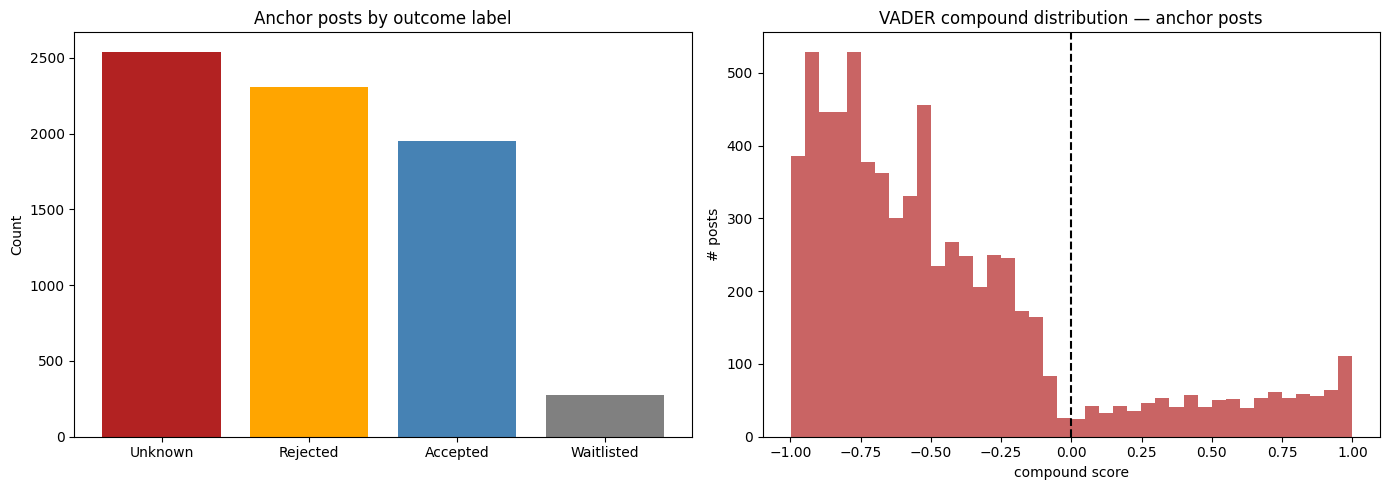

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outcome breakdown of anchor posts
outcome_counts = anchor_posts['outcome'].value_counts()
axes[0].bar(outcome_counts.index, outcome_counts.values, color=['firebrick','orange','steelblue','gray'])
axes[0].set_title('Anchor posts by outcome label')
axes[0].set_ylabel('Count')

# Distress distribution
axes[1].hist(anchor_posts['vader_compound'], bins=40, color='firebrick', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('VADER compound distribution — anchor posts')
axes[1].set_xlabel('compound score')
axes[1].set_ylabel('# posts')

plt.tight_layout()
plt.savefig(PIPE_DIR / 'fig_anchor_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Anchor posts by degree type
print(anchor_posts['degree_type'].value_counts())
print('\nMean distress by outcome:')
display(anchor_posts.groupby('outcome')[['vader_compound', 'distress_score']].mean().round(4))

degree_type
Other      3652
PhD        2184
Masters    1239
Name: count, dtype: int64

Mean distress by outcome:


,vader_compound,distress_score
outcome,,
Accepted,-0.3790,0.1257
Rejected,-0.5088,0.1627
Unknown,-0.4487,0.1552
Waitlisted,-0.3689,0.1305
